# **03_ML Medical No-show**

# Section 1 - Notebook Objective and Modelling Goal

This notebook develops and evaluates machine learning models to predict whether a patient is likely to miss their appointment.

The modelling stage builds on the cleaned dataset created during ETL and the key patterns identified during EDA. The aim is to compare a simple baseline model with a more flexible comparison model and identify which approach is more suitable for this business problem.

From an operational perspective, this type of model could help healthcare providers better understand no-show risk and support more targeted intervention planning.

---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\ryan_\\VS-code-projects\\medical-appointment-no-show-analytics\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\ryan_\\VS-code-projects\\medical-appointment-no-show-analytics'

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# notebook display settings
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

# Section 2 - Load and Review Modelling Dataset

In this section, the cleaned dataset is loaded and checked before modelling begins.

The purpose of this step is to confirm that the correct version of the dataset is being used, review its overall shape, and make sure the expected columns from ETL and EDA are available for modelling.

In [5]:
#Load cleaned dataset from 01_ETL.ipynb

file_path = current_dir + "\data\processed\medical_appointments_cleaned.csv"
df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
display(df.head())
display(df.info())

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
C:\Users\ryan_\AppData\Local\Temp\ipykernel_35652\3548873665.py:3: SyntaxWarning: invalid escape sequence '\d'
  file_path = current_dir + "\data\processed\medical_appointments_cleaned.csv"


Dataset shape: (110521, 21)


,Gender,scheduled_day,appointment_day,age,Neighbourhood,Scholarship,hypertension,Diabetes,Alcoholism,handicap,sms_received,no_show,scheduled_date,appointment_date,wait_days,scheduled_hour,scheduled_day_of_week,appointment_day_of_week,no_show_flag,has_handicap,same_day_appointment
0,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,No,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,0,18,Friday,Friday,0,0,1
1,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,No,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,0,16,Friday,Friday,0,0,1
2,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,No,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,0,16,Friday,Friday,0,0,1
3,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,0,17,Friday,Friday,0,0,1
4,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,1,1,0,0,0,No,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,0,16,Friday,Friday,0,0,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110521 entries, 0 to 110520
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   Gender                   110521 non-null  object
 1   scheduled_day            110521 non-null  object
 2   appointment_day          110521 non-null  object
 3   age                      110521 non-null  int64 
 4   Neighbourhood            110521 non-null  object
 5   Scholarship              110521 non-null  int64 
 6   hypertension             110521 non-null  int64 
 7   Diabetes                 110521 non-null  int64 
 8   Alcoholism               110521 non-null  int64 
 9   handicap                 110521 non-null  int64 
 10  sms_received             110521 non-null  int64 
 11  no_show                  110521 non-null  object
 12  scheduled_date           110521 non-null  object
 13  appointment_date         110521 non-null  object
 14  wait_days           

None

# Section 3 - Review Target Variable

The target variable for this project is `no_show_flag`, where 1 represents a missed appointment and 0 represents an attended appointment.

Before training any models, the target distribution is reviewed to understand whether the classes are balanced. This is important because class imbalance can affect how model performance should be interpreted.

no_show_flag value counts:
no_show_flag
0    88207
1    22314
Name: count, dtype: int64

no_show_flag percentage distribution:
no_show_flag
0    79.81
1    20.19
Name: proportion, dtype: float64


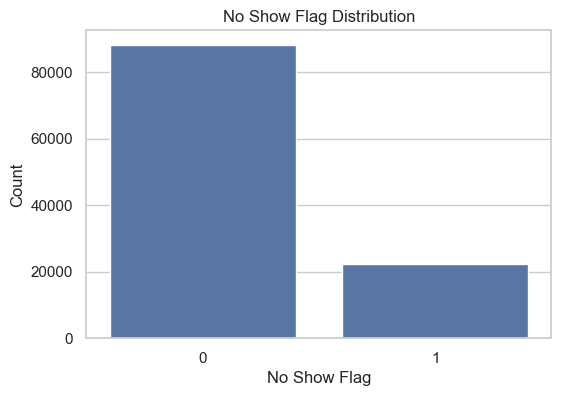

In [6]:
print("no_show_flag value counts:")
print(df["no_show_flag"].value_counts())
print("\nno_show_flag percentage distribution:")
print(round(df["no_show_flag"].value_counts(normalize=True) * 100, 2))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="no_show_flag")
plt.title("No Show Flag Distribution")
plt.xlabel("No Show Flag")
plt.ylabel("Count")
plt.show()

The target variable is imbalanced, with 79.8% of appointments recorded as attended and 20.2% recorded as no-shows. This means the classes are not evenly distributed, so accuracy alone would not be a sufficient measure of model performance. For this reason, additional metrics such as precision, recall, F1-score, and the confusion matrix will be used when evaluating the models.

# Section 4 - Define Features and Target

In this section, the target variable `no_show_flag` is separated from the feature set used for modelling.

Columns that should not be used for prediction are removed, including the text version of the target and raw date fields that overlap with engineered features already created during ETL. Redundant columns such as `same_day_appointment` and `handicap` are also excluded to reduce duplication and keep the model easier to interpret.

Based on the earlier correlation heatmap and feature review (`02_vis.ipynb`), some engineered columns were found to overlap closely with existing variables. Where two columns captured almost the same information, only one was retained in the initial model to reduce redundancy and keep the feature set more interpretable.

In [7]:
# Define target
y = df["no_show_flag"]

# Define feature set
X = df.drop(columns=[
    "no_show_flag",          # target
    "no_show",               # text version of target
    "scheduled_day",         # raw datetime, overlaps with derived fields
    "appointment_day",       # raw datetime, overlaps with derived fields
    "scheduled_date",        # raw date version, overlaps with wait_days / weekday
    "appointment_date",      # raw date version, overlaps with wait_days / weekday
    "same_day_appointment",  # overlaps with wait_days
    "handicap"               # keeping has_handicap instead
], errors="ignore")

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nSelected features:")
print(X.columns.tolist())

Feature matrix shape: (110521, 13)
Target shape: (110521,)

Selected features:
['Gender', 'age', 'Neighbourhood', 'Scholarship', 'hypertension', 'Diabetes', 'Alcoholism', 'sms_received', 'wait_days', 'scheduled_hour', 'scheduled_day_of_week', 'appointment_day_of_week', 'has_handicap']


# Section 5 - Review Feature Types

The selected modelling features are reviewed by data type and separated into numeric and categorical groups.

This is important because each feature type requires different preprocessing steps. Numeric features can be scaled if needed, while categorical features must be encoded before they can be used in machine learning models.

In [8]:
# Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['age', 'Scholarship', 'hypertension', 'Diabetes', 'Alcoholism', 'sms_received', 'wait_days', 'scheduled_hour', 'has_handicap']

Categorical features:
['Gender', 'Neighbourhood', 'scheduled_day_of_week', 'appointment_day_of_week']


# Section 6 - Train-Test Split

The dataset is split into training and test sets so that model performance can be evaluated on unseen data.

A stratified split is used to preserve the class balance of the target variable in both sets. This improves the consistency and reliability of the evaluation by ensuring that the training and test data reflect the same no-show distribution.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\ny_train distribution:")
print(y_train.value_counts(normalize=True).round(4))

print("\ny_test distribution:")
print(y_test.value_counts(normalize=True).round(4))

print("\nTraining rows:", len(X_train))
print("Test rows:", len(X_test))

X_train shape: (88416, 13)
X_test shape: (22105, 13)

y_train distribution:
no_show_flag
0    0.7981
1    0.2019
Name: proportion, dtype: float64

y_test distribution:
no_show_flag
0    0.7981
1    0.2019
Name: proportion, dtype: float64

Training rows: 88416
Test rows: 22105


The class proportions remain almost identical across the training and test sets, confirming that stratification worked as intended. This is important because the target variable is moderately imbalanced, and an unstratified split could have produced a less reliable evaluation dataset.

# Section 6A - Validation Split for Threshold Turning  

To support optional threshold tuning, the training data is split again into a smaller training set and a validation set.

The validation set is used to test alternative probability thresholds without using the final test set during model refinement. This helps keep the final evaluation more reliable.

In [10]:
# Split training data again into train/validation
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("X_train_sub shape:", X_train_sub.shape)
print("X_val shape:", X_val.shape)

print("\ny_train_sub distribution:")
print(y_train_sub.value_counts(normalize=True).round(4))

print("\ny_val distribution:")
print(y_val.value_counts(normalize=True).round(4))

X_train_sub shape: (70732, 13)
X_val shape: (17684, 13)

y_train_sub distribution:
no_show_flag
0    0.7981
1    0.2019
Name: proportion, dtype: float64

y_val distribution:
no_show_flag
0    0.7981
1    0.2019
Name: proportion, dtype: float64


# Section 7 - Preprocessing Pipeline

A preprocessing pipeline is created to prepare the data for modelling.

Numeric and categorical features are handled separately using appropriate transformations. Keeping preprocessing inside a pipeline helps reduce leakage risk and makes it easier to compare multiple models in a consistent way.

In [11]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'Scholarship', 'hypertension',
                                  'Diabetes', 'Alcoholism', 'sms_received',
                                  'wait_days', 'scheduled_hour',
                                  'has_handicap']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'))]),
                                 ['Gender', 'Neighbourhood',
                                  'scheduled_day_of_week',
                                  'appointment_day_of_week'])])

The preprocessing pipeline prepares the selected features for modelling by applying different transformations to numeric and categorical variables. This ensures that continuous features are standardised and categorical fields are encoded consistently. Using a pipeline-based approach also helps reduce data leakage and supports fair comparison between models.

# Section 8 - Baseline Model: Logistic Regression

Logistic Regression is used as the baseline model for this project.

This model provides a strong starting point because it is simple, commonly used for classification tasks, and relatively easy to interpret. It gives a benchmark against which a more advanced model can be compared.

In [12]:
# Build Logistic Regression pipeline
log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight="balanced"
    ))
])

# Fit model on training data
log_reg_pipeline.fit(X_train_sub, y_train_sub)

log_reg_val_pred = log_reg_pipeline.predict(X_val)
log_reg_val_prob = log_reg_pipeline.predict_proba(X_val)[:, 1]

log_reg_y_pred = log_reg_pipeline.predict(X_test)
log_reg_y_prob = log_reg_pipeline.predict_proba(X_test)[:, 1]

print("Logistic Regression model trained successfully.")
print("Predictions and probability scores generated for the test set.")

Logistic Regression model trained successfully.
Predictions and probability scores generated for the test set.


Because the target variable is moderately imbalanced, `class_weight="balanced"` is used so that the model gives more attention to the minority no-show class.
The Logistic Regression baseline model was trained using the preprocessing pipeline and evaluated on the unseen test set. Because the target variable is moderately imbalanced, class weighting was applied to help the model give appropriate attention to the no-show class. Both class predictions and probability scores were generated for use in the evaluation section.

# Section 9 - Comparison Model: Random Forest

Random Forest is used as the comparison model.

Unlike Logistic Regression, Random Forest can capture more complex and non-linear relationships in the data. This makes it a useful second model for assessing whether a more flexible approach improves predictive performance.

In [13]:

from sklearn.pipeline import Pipeline

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_leaf=5,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train_sub, y_train_sub)

rf_val_pred = rf_pipeline.predict(X_val)
rf_val_prob = rf_pipeline.predict_proba(X_val)[:, 1]

rf_y_pred = rf_pipeline.predict(X_test)
rf_y_prob = rf_pipeline.predict_proba(X_test)[:, 1]

print("Random Forest model trained successfully.")
print("Predictions and probability scores generated for the test set.")

Random Forest model trained successfully.
Predictions and probability scores generated for the test set.


The initial Random Forest setup proved relatively slow to train on the full feature set, likely due to dataset size and one-hot encoded categorical variables such as neighbourhood. A lighter configuration was therefore used to keep the modelling workflow practical while still providing a meaningful comparison model.

The Random Forest model is used as a comparison model because it can capture more complex and non-linear relationships than Logistic Regression. As with the baseline model, class weighting is used to help account for the moderately imbalanced target variable.

# Section 10 - Model Evaluation and Comparison

The models are evaluated using a range of classification metrics rather than accuracy alone.

This includes measures such as precision, recall, F1-score, and the confusion matrix. These metrics provide a more complete view of model performance, especially when predicting missed appointments where one class may be more important to identify correctly.

In [14]:

def evaluate_model(model_name, y_true, y_pred, y_prob):
    """
    Return common classification metrics in a dictionary.
    """
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1_score": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_prob)
    }

In [15]:
# Evaluate both models
log_reg_metrics = evaluate_model("Logistic Regression", y_test, log_reg_y_pred, log_reg_y_prob)
rf_metrics = evaluate_model("Random Forest", y_test, rf_y_pred, rf_y_prob)

# Create comparison table
metrics_df = pd.DataFrame([log_reg_metrics, rf_metrics])

# Round for readability
metrics_df = metrics_df.round(4)

display(metrics_df)

,model,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.6546,0.3107,0.5832,0.4055,0.6687
1,Random Forest,0.5678,0.2985,0.8449,0.4412,0.7193


In [16]:
print("Logistic Regression Classification Report")
print(classification_report(y_test, log_reg_y_pred))

print("\nRandom Forest Classification Report")
print(classification_report(y_test, rf_y_pred))

Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.86      0.67      0.76     17642
           1       0.31      0.58      0.41      4463

    accuracy                           0.65     22105
   macro avg       0.59      0.63      0.58     22105
weighted avg       0.75      0.65      0.69     22105


Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.93      0.50      0.65     17642
           1       0.30      0.84      0.44      4463

    accuracy                           0.57     22105
   macro avg       0.61      0.67      0.54     22105
weighted avg       0.80      0.57      0.61     22105



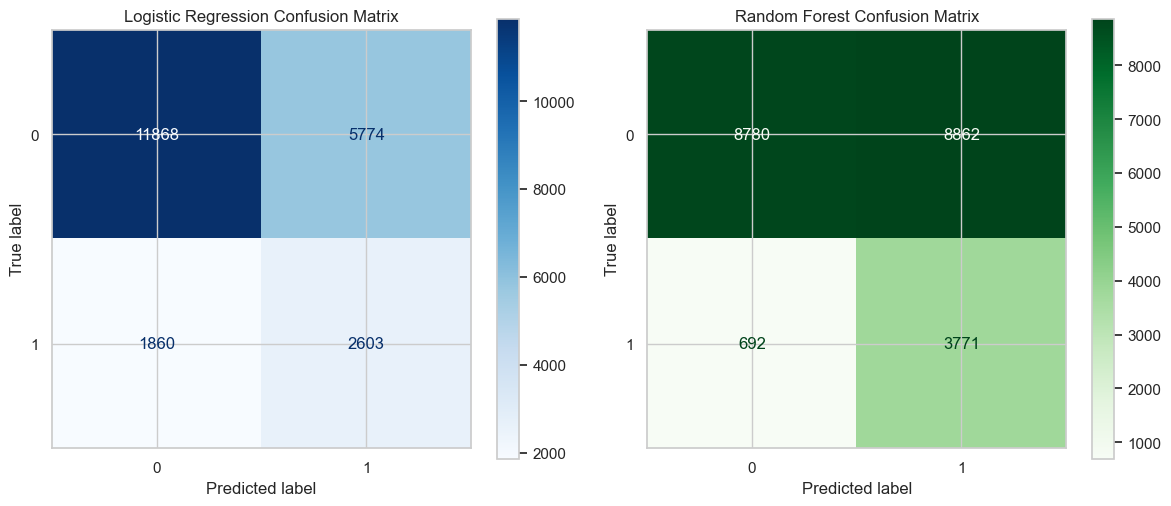

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, log_reg_y_pred, ax=axes[0], cmap="Blues"
)
axes[0].set_title("Logistic Regression Confusion Matrix")

ConfusionMatrixDisplay.from_predictions(
    y_test, rf_y_pred, ax=axes[1], cmap="Greens"
)
axes[1].set_title("Random Forest Confusion Matrix")

plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

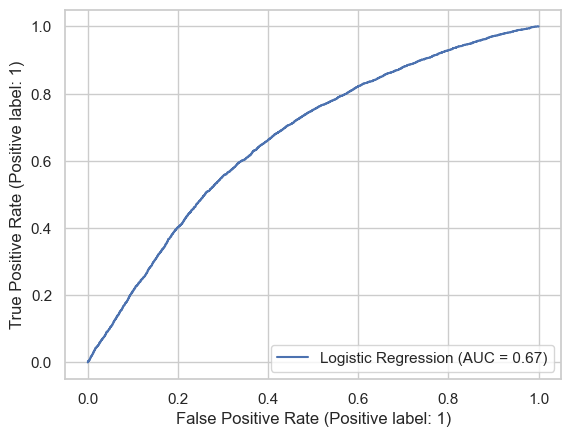

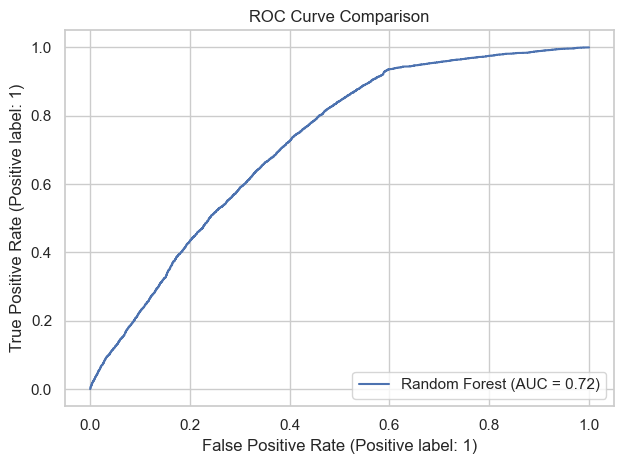

In [18]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test, log_reg_y_prob, name="Logistic Regression"
)
RocCurveDisplay.from_predictions(
    y_test, rf_y_prob, name="Random Forest"
)

plt.title("ROC Curve Comparison")
plt.tight_layout()
plt.show()

Both models are evaluated using a range of classification metrics rather than accuracy alone. This is important because the target variable is moderately imbalanced, meaning that a high accuracy score on its own could still hide weak performance when identifying the no-show class.

# Section 11 - Optional Refinement: Threshold Tuning

The default classification threshold for both models is 0.5, meaning that appointments are classified as likely no-shows when the predicted probability is at least 50%.

Because this project is particularly interested in identifying missed appointments, threshold tuning is explored as an optional refinement. This helps test whether a different cut-off produces a better balance between recall, precision, and F1-score for the no-show class.

In [19]:



def evaluate_thresholds(y_true, y_prob, thresholds):
    results = []

    for threshold in thresholds:
        y_pred_threshold = (y_prob >= threshold).astype(int)

        results.append({
            "threshold": threshold,
            "accuracy": accuracy_score(y_true, y_pred_threshold),
            "precision": precision_score(y_true, y_pred_threshold, zero_division=0),
            "recall": recall_score(y_true, y_pred_threshold, zero_division=0),
            "f1_score": f1_score(y_true, y_pred_threshold, zero_division=0)
        })

    return pd.DataFrame(results)

In [20]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

rf_threshold_results = evaluate_thresholds(y_val, rf_val_prob, thresholds)
display(rf_threshold_results.round(4))

,threshold,accuracy,precision,recall,f1_score
0,0.3,0.4938,0.2796,0.9560,0.4326
1,0.4,0.5204,0.2872,0.9286,0.4388
2,0.5,0.5738,0.3030,0.8549,0.4475
3,0.6,0.7382,0.3654,0.4031,0.3833
4,0.7,0.7980,0.2500,0.0003,0.0006


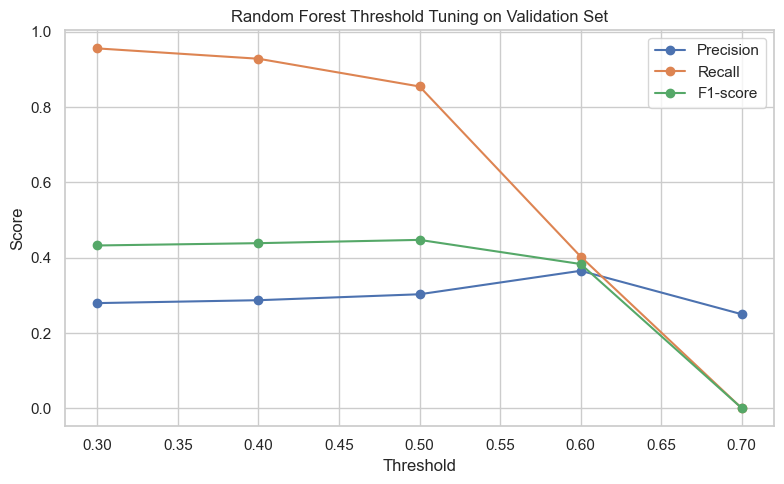

In [22]:

plt.figure(figsize=(8, 5))
plt.plot(rf_threshold_results["threshold"], rf_threshold_results["precision"], marker="o", label="Precision")
plt.plot(rf_threshold_results["threshold"], rf_threshold_results["recall"], marker="o", label="Recall")
plt.plot(rf_threshold_results["threshold"], rf_threshold_results["f1_score"], marker="o", label="F1-score")

plt.title("Random Forest Threshold Tuning on Validation Set")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

Threshold tuning was explored for the Random Forest model using the validation set to test whether a different probability cut-off would improve the balance between recall and precision.

The results showed that lower thresholds such as 0.3 and 0.4 produced very high recall, but also a large number of false positives. A threshold of 0.5 gave the best overall balance, with the highest F1-score (0.4475), while still maintaining strong recall (0.8549). Based on this, the default 0.5 threshold was retained for the final model.

# Section 12 - Model Interpretation

After evaluating model performance, the next step is to interpret what the models are learning.

This section focuses on feature importance or model coefficients to identify which variables appear most influential in predicting no-shows. These results can then be compared back to the earlier EDA findings.

# Section 13 - Model Selection Decision

This section identifies which model should be taken forward based on the evaluation results.

The final choice should not be based on accuracy alone. Instead, the decision should reflect the project objective, the balance of evaluation metrics, and how suitable the model is for the business problem.

Threshold tuning was explored as an optional refinement for the Random Forest model. Although lower thresholds increased recall slightly, they also increased false positives and reduced the overall balance of performance. Since the 0.5 threshold produced the highest F1-score, it was retained as the final decision threshold.

# Section 14 - Ethical Considerations, Bias and Governance

Machine learning predictions in healthcare-related settings should be interpreted carefully and used responsibly.

Although the dataset is anonymised, some variables such as neighbourhood, scholarship status, age, and health conditions may reflect wider structural inequalities. For this reason, the model should be viewed as a support tool for planning and service improvement, rather than a basis for penalising or unfairly targeting individual patients.

# Section 15 - Limitations

There are several limitations to this modelling approach.

The model is based on historical data from a single dataset and the results show association rather than causation. In addition, some variables may overlap, some useful real-world factors are not available in the data, and the model may not generalise perfectly to future appointment behaviour.

# Section 16 - Next Steps

There are several ways this project could be improved in a future iteration.

Possible next steps include testing additional models, tuning hyperparameters, adjusting the classification threshold, and exploring how predictions could be integrated into a dashboard or decision-support workflow. Additional external features related to access or transport could also strengthen the model if available.

# Section 17 - Save Model Outputs

The final step is to save key modelling outputs in a structured project folder.

This may include model metrics, feature importance results, confusion matrix images, or the trained model pipeline itself. Saving outputs in a versioned location helps support reproducibility and improves project organisation.

# Section 18 - ML Summary

This notebook developed and compared two classification models to predict appointment no-shows using the cleaned dataset produced earlier in the project.

The final model choice was based on a combination of predictive performance, interpretability, and suitability for the business problem. The modelling results will be used alongside the earlier EDA findings to support the final project conclusions and recommendations.